<a href="https://colab.research.google.com/github/Frankuccino/neuralnet/blob/main/micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Micrograd Neuron: Value


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x + 5 # this is a quadratic polynomial (trinomial)

In [ ]:
f(3.0)

20.0

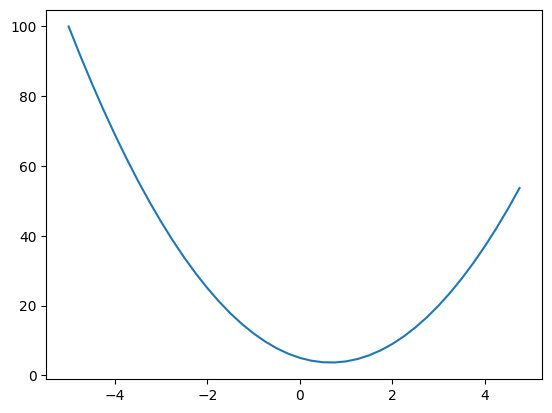

In [ ]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
# No one in neural networks actually writes out the expression for the neural net,
# it would be a massive expression (thousands of terms), no one actually derives
# the derivative, of course. We won't go to the symbolic approach but rather look
# at the definition of derivative and just make sure we really understand what
# derivative is measuring and what it's telling you about the function.

In [ ]:
h = 0.0000001 # fifteen 0s causes the computer memory's finite limitations to fail.
x = 2/3
(f(x + h) - f(x))/h # so basically this is the slope.

2.9753977059954195e-07

In [ ]:
# let's get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
# this is a function with 3 scalar inputs: a, b, and c. Three inputs in our
# expression graph and a single output d.

print(d)

4.0


In [ ]:
# What we have to do is we'd like to again look at the derivatives of d
# with respect to a, b, and c
h = 0.0001

# inputs - these are the point a,b,c which we're going to be evaluating the
# derivative of d with all respect to a, b, c
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c

# CASE A: we're going to look at the derivative of d with respect to a
# a += h

# CASE B:
# b += h

# CASE C:
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)
# this is slope of a secant line on a
# curve represents the average rate of change over that interval
# SLOPE: d2 - d1 is how much the function increased, when we increment the
# specific input that we're interested in (which was a)
# then this is normalized by h to get the slope

# CASE A: to think of it intuitively about this derivative:
# a will be slightly more positive, but b is a negative number.
# so a is slightly more positive, and because b is -3,
# we're actually adding less to d. So you'd actually expect the
# value of the function will go down.

# differentiating a * b + c with respect to a, gives you just b.
# and indeed the value of b is negative, which is the derivative we have.


# CASE B: so if we bump b by a little bit in a positive direction,
# we'd get different slopes, so what is the influence of b on the output of d
# so if we bump b by a tiny amount in a positive direction.
# Then because a is positive, we'll be adding more to d.
# Now what's the sensitivity what is the slope of that addition.


# CASE C: if c gets bump by a tiny amount, then a * b is unaffected and now
# c becomes slightly bit higher. What does that do to the function?
# it makes it slightly bit higher because we're simply adding c;
# it makes it slightly bit higher at the exact same amount that we added to c.
# that tells you that the slope is 1.
# that will be the rate in which d will increase as we scale c.

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [ ]:
# We now have some intuitive sense of what this derivative is telling you
# about the function and we'd like to move to neural networks.
# As mentioned, neural networks will be a pretty massive mathematical expressions
# so we need some data structures to maintain these expressions.

# So that's what we're going to start to build out now.
# We're going to build out this value object that you can see in micrograd readme page.

In [ ]:
# This is be the very first skeleton of the first very simple value object.
# with the grad (gradient) set to 0.0 , that means at initialization we're
# assuming that every value does not impact/affect the output.
# that means changing this variable is not changing the loss function.
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    # if other is an instance of value, otherwise simply wrap it with the Value class
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float for now"
    out = Value(self.data**other, (self, ), f'**{other}')

    def _backward():
      self.grad += other * (self.data ** (other-1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def exp(self): # exp is going to mirror tanh
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += math.exp(x) * out.grad
    out._backward = _backward

    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

  def __radd__(self, other):
      return self + other


# Finally, we're going to hide this functionality and hide it inside the value class


    # 58:30 - The only thing that matters is that we know how to differentiate
    # through any one function. So we take some inputs and we make an output.
    # the only thing that matters, it can be arbitrarily complex function,
    # as long as you know how to create the local derivative
    # if you know the local derivative of how the inputs impact the output,
    # then that's all you need.
# So we're going to cluster up all of this expression (tanh - hyperbolic tangent)
    # we're not going to break it down to its atomic pieces, we're just going to
    # directly implement tanh, so let's do that. (check def exp(self))



# So class Value, takes a single scalar value that it wraps and keeps track of.
# Python will internally return the repr function to return that string

# You have to use this special underscore __ methods in Python to define these
# operators for these objects like addition (+)
# a + b = a.__add__(b)


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e '
d = e + c; d.label = 'd'

# So let's make this expression just one layer deeper, so d will not be the final
# output node, instead, after d, we're going to create a new value object called f
f = Value(-2.0, label='f')
# L will be the output of our graph.
L = d * f; L.label='L'
L

Value(data=-8.0)

In [ ]:
# @title
# Now what we're missing is the connective tissue of this expression.
# as mentioned, we want to keep this expression graphs so we need to know and
# keep pointers about what values produce what other values.

# That mean's we'll introduce a new variable children,
# by default it will be an empty tuple, and at the same time we'll keep a
# slightly different variable in the class which we call _prev
# which will be the set of children. The reason if for efficiency.
# so _children will be a tuple, but when we maintain it in the Class,
# it'll be just this set data structure


# Now, when we are creating a value through addition or multiplication,
# we're going to feed in the children of this value

In [ ]:
# @title
d._prev
# we can now then see the children of this derivative
# which is the value of -6 and the value of 10
# of course this is the value resulting from a*b and the c value

# So no we know the children of every single value but,
# we don't know what operation created this value so we need one more element.

# so we added _op and by default this is the empty set for leaves

{Value(data=-6.0), Value(data=10.0)}

In [ ]:
# @title
d._op
# So now, we don't just have d._prev we also have d._op and we know that
# d was produced by an addition of those two values.

'+'

In [ ]:
# @title
# So now we have the full mathematical expression and we're building out this
# data structure and we know exaclty how each value came to be:
# by what expression and what other values.

# Now since these expressions are about to get quite bit larger, we'd like
# a way to nicely visualize these expressions that we're building out.

In [ ]:
from graphviz import Digraph

# Trace enumerates all of the nodes and edges in the graph.
def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular (`record`) node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % ( n.label, n.data, n.grad ), shape='record')

    if n._op:
      #if this value is a result of some operation, create n op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id (n1)), str(id(n2)) + n2._op)

  return dot



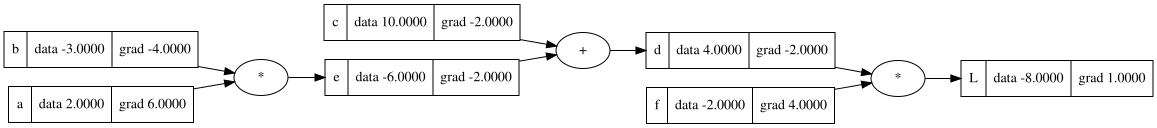

In [ ]:
L.backward()
draw_dot(L)

In [ ]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-46.8


In [ ]:
# @title
# So let's get a recap of what we've done so far:

# We are able to build out mathematical expressions using only plus and times so far
# They are scalar valued along the way, and we can do this forward pass and build out
# a mathematical expression.

# so we have multiple inputs here, a, b, c, f
# going through a mathematical expression that produces a single output L
# and this here (draw_dot(L)) is visualizing the forward pass.
# so the output of the forward pass is -8 . That's the value.

# Now, what we'd like to do next, is we'd like to run backpropagation.
# With backpropagation, we are going to start here (at the end), at L
# and we're going to reverse and calculate the gradient
# along these intermediate values.

# What we're really computing: for every single value here,
# we're going to compute the derivative of that node with respect to L
# sothe derivative of L with respect to L is just 1

# then we're going to derive the derivative of L
# with respect to f,
# with respect to d,
# with respect to c,
# with respect to e,
# with respect to b, and
# with respect to a

# In neural network setting, you'd be interested in the derivative of basically
# this Loss function L, with respect to the weights of the neural network.
# We'll need to know how those weights are impacting the loss function.

# we'll basically be interested in the derivative of the output
# with respect to some of its leaf nodes, and those leaf nodes will be the
# weights of the neural net.
# and the other leaf nodes of course will be the data itself.

# We will not want or use the derivative of the loss function with respect to data
# because the data is fixed, but the weights will be iterated on;
# using the gradient information.

In [ ]:
# @title
# So what we'll do next is we're going to create a variable inside the Value class
# that maintains the derivative of L with respect to that value, we'll call it grad.

# Now, we're just getting ready to calculate the backpropagation.
# again, grad (gradient) is representing
  # the derivative of the output with respect to this value.
# Let's now fill in those gradients that actually do backpropagation manually.

In [ ]:
# @title
# L = d * f
# dL/dd = f

# this means we can just derive is because the proof would be fairly straigtforward.
(f(x+h) - f(x))/ h # This is the definition of a derivative.

# as a limit of h goes to 0 of this kind of expression.
# so when we have L is d time f,

# then increading d by h will give us the output of
((d+h)*f - d*f)/h # expand# adding on this would be
(d*f + h*f - d*f)/h
(h*f)/h
f
# this basically means doing a derivative of L in respect to d just gives us f.
# symmetrically, dL/df = d

In [ ]:
# @title
L.grad = 1.0 # this is our manual backpropagation.
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = (-2.0 * -3.0) # so the (dL/de * de/da) applying the chain rule. da is b.
b.grad = (-2.0 * 2) # dL/de * de/db

In [ ]:
# What's the derivative of L with respect to L?
# In other words, if we change L by a tiny amount of h, how much does L change?
# well, it changes by h. So it's proportional therefore derivative will be 1.

# we can of course estimate these numerical gradients numerically just like what
# we've seen before.

def lol():
  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e '
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label='L'
  L1 = L.data

  # So this will be measuring the derivative of L with respect to a.
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e '
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f') # delta here is gradient of 4
  L = d * f; L.label='L'
  L2 = L.data
  # so we simply want the rise over run
  print((L2 - L1)/h)

lol()

# can now assume we'll be doing backpropagation iterating backwards
# getting the gradient as the derivative value

-3.9999999999995595


In [ ]:
# Gradient check is like deriving this backpropagation and derivative
# with all respect to all the intermediate results and then numerical gradient
# is just estimating it using small step size.

# Now, we're getting to the crux of backpropagation.

# This is the most important node to understand because if you understand
# the gradient for this node, you understand all backpropagation and
# all training of neural nets

# So we need to derive
# dL / dc - In other words, the derivative of L with respect to c

# We know the derivative of L with respect to d and f, but how is L
# sensitive to c, how does that impact L through d.
# so we know how c impacts d.
# so just very intuitively, if you know the impact that c is having on d
# and the impact of d having on L, then you should be able to put that
# information together, to figure out how c impacts L.

# indeed this is what actually we can do.
# So just concentrating on d first, let's first look at how derivative
# of d with respect to c

# In other words - what is:
# dd / dc ?
# here we know that d = e + c
# and as you know, differentiating c + e with respect to c is 1.0
# now going back further with - (f(x+h) - f(x))/h -
# That's definition of derivative as h goes to 0
# so focusing here, on c, and its effect on d.
# It'll be - ((c+h + e) - (c + e))/h
# expanding it, it'll be (c + h + e - c - e)/h
# h/h - everything cancels
# 1.0

# By symmetry,
# dd / de = 1.0

# so the expression is very simple and this is the local derivative
# this is a little plus node, this plus node doesn't know anything about
# the rest of the graph that's embedded in. All of it knows is it did addition.
# it took an e and c, added them, and created a d
# and this plus node also knows the local influence of c on d,
# or rather the derivative of d with respect to c.
# and it also knows the derivative of d with respect to e.

# But that's not what we want, that's just a local derivative,
# what we actually want is dL / dc
# L here is one step away, but in the general case, this (+) node
# could be embedded in a massive graph

# Again, we know how L impacts d, and now we know how c and e impacts d
# how do we put that information together to write dL/dc?

# The answer is the Chain rule in calculus
# this chain rule tells you how we chain the derivatives together correctly
# z depends on y, which y itself depends on x
# then z depends on x as well, via the intermediate variable y.
# dz/dx = dz/dy * dy/dx

# AMAZING!
# so to differentiate through a function composition, we have to apply
# a multiplication of those derivatives.
# to think of it intuitively:
# "if a car travels twice as fast as a bicycle and the bicycle is four times
# as fast as a walking man, then the car travels 2 x 4 = 8 times as fast as the man"
# so the correct thing to do so is to do sort of multiply.
# So that justifies the chain rule intuitively.

# KNOW:
# dL / dd = -2.0
# dd / dc = 1.0

# WANT:
# dL / dc = (dL / dd) * (dd / dc)
# that simply is just -2.0, since -2.0*1.0 is still the same -2.0

# so what a (+) node does, it just routes the gradient because the plus nodes
# local derivatives are just one, and so in the chain rule, 1 times dL/dd
# is just dL/dd. And so that derivative just get routed to both c and e

In [ ]:
# So this backpropagation signal which is carrying the information of like
# what is the derivative of L with respect to all the intermediate nodes
# we can imagine it almost like flowing backwards through the graph
# and a (+) node will simply distribute the derivative to all the
# children nodes of it.

# So now, we're going to recurse our way backwards again,
# and we're again going to apply the chain rule

# So I assume we'll be needing the formulas as (before continuing watching...)
# de/da and de/db
# We know that e = a * b
# (((a + h) * b) - (a * b))/h
# h * b / h = b
# so de/da = b

# Now verifying my knowledge (this is Andrej's explanation...)
# so we now dL/de = -2.0 # we know the derivative of L with respect to e
# Now we want, dL/da and the chain rule is just telling us that, that's just
# dL/da = (dL/de) * (de/da) - so the local gradient is that de/da

# So I'm a little (*) node inside a massive graph and I only know that I did
# a times b and I produced an e

# so now, what's de/da and de/db?
# so because we have e = a * b
# we're askign what's de/da
# you'll just get b. the value of b which in this case -3.0

# so again, b.grad = dL/db
# e = a * b
# dL/de - derivate of L with respect to e (gradient) = -2.0
# de/db - derivative of e with respect to b = ?
# ((a * (b + h)) - (a * b))/h
# b cancels b, h cancels h. we have a remain
# so de/db = a or 2.

# dL/db = dL/de * de/db


In [ ]:
# So that's it, that's the manual backgpropagation, all the way from L
# to all the leaf nodes and we've done it piece by piece.

# so to summarize what i've learned, with the backpropagation
# derivative values for (+) nodes, from output with respect to x + y
# they will simply carry the gradient of their sum's gradient.

# and with the derivative values for (*) nodes
# they simply have the value of their partner multiplied by
# the gradient of their predecessor.

# The formula for the backpropagation derivative uses Calculuis Chain Rule.
# to get the gradient descent value:
# We know the intermediate derivative for the (+) and (*) nodes intuitively
# And we simply use the local gradient value.

# that means the gradient values a

In [ ]:
# Andrej's summary:
# So what we've done as we saw, we iterated through all the nodes one by one
# and locally apply the chain rule.
# We always know the derivative of L with respect to this little output
# and then we look at how this output was produced. This output was produced
# through some operation and we have the pointers to the children nodes of this
# operation, and so in this little operation, we know what the
# local derivatives are, and we just multiply them onto the derivative always.

# So we just go through and recursively multiply on the local derivatives
# and that's what backpropagation is: It isjust a recursive application of
# the chain rule backwards through the computational graph.

In [ ]:
# Let's see this power in action just very briefly
# we're going to try nudge our inputs to make L go up.

In [ ]:
# We're going to for an example of a manual backpropagation a bit more complex
# and useful example; we're going to backpropagate through a neuron.
# We want to eventually build up neural networks. In a simple case this is a
# Multilateral perceptrons as they're called - this is a two layer neural net

# It got these hidden layers made up of neurons and these neurons are
# fully connected to each other.
# Now, biologically, neurons are very complicated devices, but we have very
# simple mathematical models of them. (Cs231n Convolutional Neural Networks)

# So you have some Input axis and then you have these Synapses that have weights on them
# The Synapse interacts with the input to this neuron multiplicatively
# so what flows to the Cell Body of this Neuron is w * x.
# But there many inputs so there are multiple w * x's flowing into the cell body.
# The cell body also have some Bias, and this bias can make it trigger more happy
# or a bit less trigger happy regardless of the input.

# But basically we're taking all the w * x of all the inputs, adding the bias
# and then we take it through an activation function.
# This activation function is some kind of squashing function, like sigmoid or 10h

# We're going to use the 10h in this example.

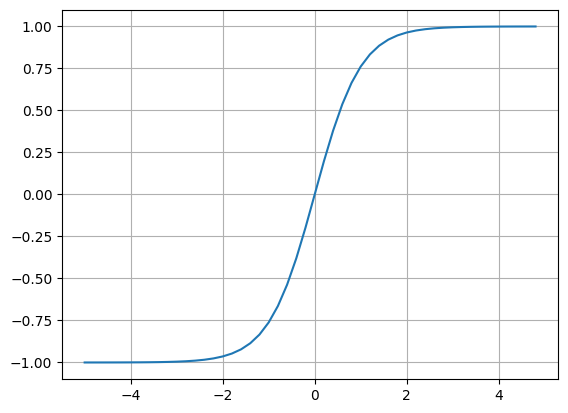

In [ ]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();
# so this is the tanh
# you can see that the inputs as they come in, gets squashed on the y coordinate
# so right at 0, we get exactly 0
# and then as you go more positive in the input,
# then you'll see that the function will only go up to 1 and plateau out

# so if you pass very positive inputs, we're gonna cap it smoothly at 1.
# and at negative side, we're going to cap it smoothly to -1.
# so that's 10h - that's the squashing function/activation function

In [ ]:
# and what comes out of this neuron is just the activation function applied
# to the dot product of the weights and the inputs.
# So let's write one out.

In [ ]:
# inputs x1, x2 - the two-dimensional neurons (axon from a neuron)
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2 - weights of neurons (synaptic strength for each input, synapse)
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# dendrites (axon multiplied by the synapse - input * weight)
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

# dendrites combined together for the - cell body (summation of dendrites)
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# cell body - summation of dendrites added with the bias.
n  = x1w1x2w2 + b; n.label = 'n'

# so now, n is the raw cell body without the activation function
# draw_dot(n)

# now we're going to take it through an activation function (tanh - hyperbolic function)
# so that we produce the output, but we also need to implement the tanh
# we can't make a tanh out of just pluses or times
# you also need exponentiation (hyperbolic tangent formula), so you see there's
# some exponentiation involved that we have not implemented yet our low value node.
# we would also need to divide

# tanh - activation function
o = n.tanh(); o.label = 'o'
# now, as long as we know the derivative of tanh, then we'll be able to backpropagate
# through it.
o.backward()
# So here's the gradients for all of these leaf nodes for this two dimensional neurons that has a tanh.

# So now what we've like to do is to break up this tanh into the expounded expression

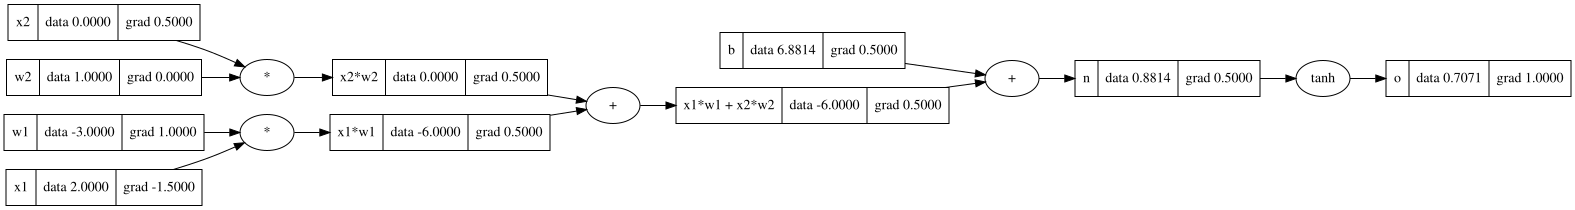

In [ ]:
draw_dot(o)

In [ ]:
# And all we do is just run this.
o.backward()
# Now that's backpropagation! place for one neuron

# Now we shouldn't be happy for ourselved because we have bad bug and we have not surfaced the bug because of some specific conditions that we have to think about right now.



In [ ]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

# Let's then build this inside the Value class itself.

[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [ ]:
# so now, we're going to  do backpropagation and fill in the gradients
# so what's the derivative of o with respect with all of the inputs here.
# Of course, in a typical neural network setting, what we really care the most
# is the derivative of these neurons on the weights specifically (w1, w2)
# because those are the weights we're going to be changing part of the optimization

# what we also have to rememeber is here, we also have only a single neuron,
# but in a neural natives, typically we have many neurons and they're connected.

# so this is only like a one small neuron, a piece of a much bigger puzzle and
# eventually there is a loss function that measures the accuracy of the neural net
# and we're backpropagating with respect to that accuracy and trying to increase it.

In [ ]:
# as a base case, we need to set the output's gradient to 1.0
o.grad = 1.0

In [ ]:
# So we don't need to do these manually since we've already added the _backward defined
o._backward()

In [ ]:
n._backward()

In [ ]:
b._backward()
# b doesn't have a backward since b is a leaf node

In [ ]:
x1w1x2w2._backward()

In [ ]:
x2w2._backward()
x1w1._backward()
# So we've finished calling the ._backward manually, through function calls now.

# We've got one last piece to get rid off which is us calling _backward manually.

# So let's think through what we are actually doing:
# We lay out a mathematical expression, and now we're trying to,
# go backwards through that expression. So going through backwards the expression
# just means that we never want to call ._backward before we've done everything after it
# so we have to do everything after it before we're ever going to call ._backward

# we have to get all of its full dependencies, everything that it depends on
# to propagate before we can continue backpropagation.

# this ordering of graphs can be achieved using topological sort.

In [ ]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [ ]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

In [ ]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [ ]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [ ]:
n.grad = 0.5

In [ ]:
# So let's start backpropagation here in the end:
# What's the derivative of o with respect to o
o.grad = 1.0

In [ ]:
# So now to backpropagate tanh, we need to know the local derivative of tanh
# o = tanh(n)
# what is do/dn = 1 - tanh(n)**2
# we already have tanh(n) do/db = 1 - o**2
# so the output value
1 - o.data**2
# so the local derivative of this tanh operation is 0.5, so that's do/dn


0.4999999999999999

In [ ]:
# So how is backpropagation going to do here, just carry over.
# So as you remember our previous example, a plus is just a distributor of gradient
# so this gradient we got from do/dn will simply flow to both of these equally
# to the cell body and the bias. (x1w1+x2w2 and b)
# again, cell body is the summation of dendrites
# going back with the (+), the local derivative for this operation is 1.0

# so again, if we want the output of this neuron to increase
# then the influence on these expressions is positive on the output
# both of them are positive contribution to the output

In [ ]:
 # Now back propagation to (*) times node, so we know that the local derivative
# is the other term multiplied by the gradient.

# derivative always tells us the influence of this (w2) on the final output
# if we wiggle w2, how is the output changing? it's not changing since we're
# multipling by 0, so because it's not changing there's no derivative.


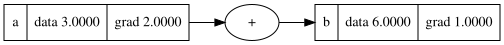

In [ ]:
# here's the bug we have atm
a = Value(3.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)



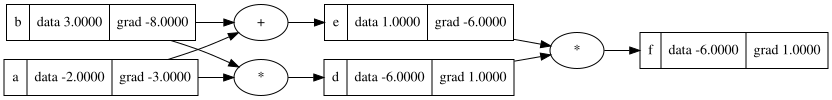

In [ ]:
# There's another way to see this in a little bit more complicated expression

a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label ='f'

f.backward()
draw_dot(f)

# So what is going to happen when a variable is used more than once?
# we're going to backpropagate from f, to e & d
# but e propagates backward and it deposits its gradients to a and b
# but then we come back to d and call backward and it overwrites those gradients at a and b.

# So that's obviously a problem.
# So the solution here is that we have to accumulate these gradients, so these gradients add.


# so basically we have no mechanism of doing gradient average recalculation (I assume)
# well, I was wrong, it's just a simple accumulation doing += for the backward gradient values instead of setting them.

# So now this is working and this is correct.


In [ ]:
# Going to the definition of tanh to its atomic definition:
# So going back, one thing we currently can't do
a = Value(2.0)

# a * 1 # We can't do this because of how we have set the Value class's __add__
# We are doing addition of the Value object like other.data and since '1' itself is not a value object, we can't do this.

# So as a matter of convenience, to create expressions like this and make them make sense, we can simply do something like this

# Okay now this works, assigning a non-Value class like an integer works now
# But here's one unfortunate obvious part.
# 2 * a
# So in python, you are free to define an rmul. So rmul is like kind of like a fallback.
# So if python can't do a 2 * a, it will check by any chance if a knows how to multiply 2, and that will be called into our rmul.
# It will check if there is an rmul in our value and because there is, it will now call that and what we'll do here is we will swap the order of the operands.
# so 2 * a will redirect to __rmul__
# and __rmul__ will basically call a * 2


# also want to do exponentiate
# a.exp()



# Okay the last thing we want to do is divide; Now, there's a slightly more poweful than division. Because division is just a special case of something a bit more powerful.
b = Value(4.0)
# we should be able to do
a / b
# now division, actually can be reshuffled as follows
# a * (1/b)
# a * (b**-1) - see the __truediv__

# we also need to know how to subtract
a - b

Value(data=-2.0)

In [ ]:
# So we still need to exponentiate and how to divide.

In [ ]:
# inputs x1, x2 - the two-dimensional neurons (axon from a neuron)
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2 - weights of neurons (synaptic strength for each input, synapse)
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# dendrites (axon multiplied by the synapse - input * weight)
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
# dendrites combined together for the - cell body (summation of dendrites)
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# cell body - summation of dendrites added with the bias.
n  = x1w1x2w2 + b; n.label = 'n'
# tanh - activation function
# ------- we're going to change how we define o (activation function - tanh)
e = (2*n).exp()
o = (e - 1) / (e + 1)
# -------
# backpropagation
o.backward()
# So here's the gradients for all of these leaf nodes for this two dimensional neurons that has a tanh.

# So now what we've like to do is to break up this tanh into the expounded expression


# So what we're expecting here is the longer graph here because we've broken up tanh into a bunch of other operations, but those operations are mathematically equivalent.

# So what we're expecting are:
# 1. The same result at the output, so the forward pass works
# 2. Because of that mathematical equivalence, we expect to see the same backwardpass and the same gradients on the leaf nodes

# The reason we put into this exercise is
# 1. We geot to practice a few more operations and writing more backward passes
# 2. We were able to illustrate your operations is totally up to you, you can implement backward passes for tiny expressions like a single individual plus or single times, or you can implement them for say, tanh, which you can see it as a composite operation because it's made up of all these more atomic operations but really all of these is kind of like a fake concept.
# All that matters is that we have some kind of inputs and some kind of output and this output is the function of the inputs in some way.

# as long as you can forward pass and backward pass of that little operation, it doesn't matter what that operation is and how composite it is.
# if you can write the local gradients, you can chain the gradient, and you can continue backpropagation, so the design of what those functions are is completely up to you.



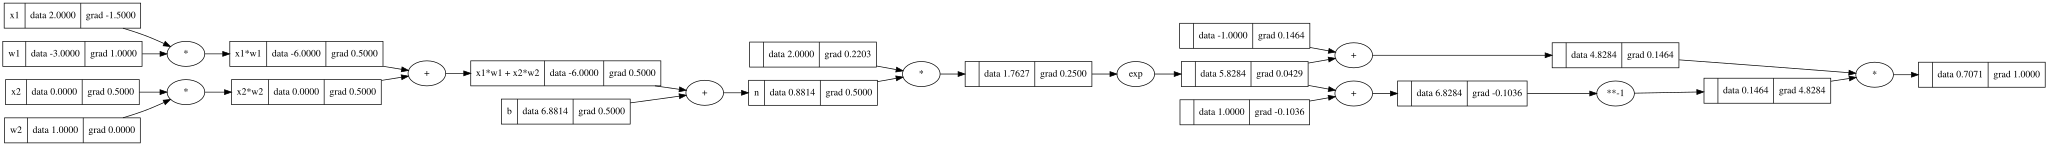

In [ ]:
draw_dot(o)

In [ ]:
# So now I'll show you how you can do the exact same thing by using a modern deep neural network library like for example, Pytorch, which Andrej roughly modeled micrograd by.

# Pytorch is something you would use in production. We'll show you how to do the exact same thing but in Pytorch API

# Micrograd is a scalar valued engine so we only have scalar values like 2.0
# But in Pytorch, everything is based around Tensors, like mentioned Tensors are
# just like n-dimensional arrays of scalars.

# So that's why things get a little bit more complicated, we just need a scalar value to tensor, a tensor with just a single element.
# But by default, when you work with pytorch, you would use more complicated tensors

In [ ]:
import torch

In [ ]:
torch.Tensor([[1,2,3],[4,5,6]])
# This Tensor by example is a 2x3 array of scalars in a single compact representation
# This is usually that you would work with in the actual libraries

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [ ]:
torch.Tensor([2.0]).dtype

torch.float32

In [ ]:
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2',w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

# So here we're creating a tensor that has only a single element 2.0 and I'm casting it to be double, python is by default using double precision for its floating point numbers, so we'd like to have everything to be identical by default.

# The data type of these tensors would be float32, so it's only using a single precision float, so we're casting it to double() so that we have float64

# Now, since these are leaf nodes, by default, Pytorch assumes that they do not require gradients, so we need to explicitly say that all of these nodes require gradients: using the '.requires_grad' set to 'True'

# So this will construct scalar valued, one-element tensors, make sure that Pytorch knows that they require gradients, these gradients by default are set to False, because of efficiency reasons, because you would not want gradients for leaf nodes like the inputs to the network and this is just trying to be efficient in the most common cases.

# So once we've defined all of our values in python, we can perform arithmetic just like we can here back in micrograd

# And there is some torch.tanh(x) also and what we get back is a Tensor again, and we can just like in micrgrad, it's got a 'data' attribute, and its got 'grad' attributes. So these Tensor objects just like in micrograd got a .data and .grad and the only difference here is that, we need to call .item() because otherwise Pytorch:
# .item() basically takes a single tensor of one element and it just returns that element stripping out the Tensor.


# So after running, this should work, and it does. So Pytorch agrees with us
# o.data.item() and o.item() will produce the same result here in PyTorch

# and o is a Tensor object, as mentioned, and it's got a backward function just like we've implemented,

# and all of these Tensor object we've defined, since we've explicitly declared the .requires_grad to True, they also have a .grad, and it is a Tensor, and we pop out the individual number with .item()


# So basically torch can do what we did in micrograd is a special case; when your Tensors are all single element tensors, but the big deal with PyTorch is everything is significantly more efficient because we are working with these tensor objects and we can do lots of operations in parallel on all of these tensors.

# But otherwise, what we've built very much agrees with the API of PyTorch.


# So now that we have some machinery to build out pretty complicated mathematical expressions, we can also start building neural nets.
# As mentioned, neural nets are just specific class of mathematical expressions.

# So we're going to start building out a neural net piece by piece and eventually we'll build out a two-layer, multi-layer perceptron as it's called and show you exactly what that means.

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


[Value Class](#scrollTo=Nu_vQxUeF3HO)

# PyTorch Neural Net


In [ ]:
# Let's start with a single individual neuron but here we're going to implement one that also subscribes to the PyTorch API in how it designs its neural network modules.

# So just like we saw that we can match the API of PyTorch in the Micrograd side, we're going to try and do that on the neural network modules

In [ ]:
import random

In [ ]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1))

  def __call__(self, x):
    # w * x + b
#    act = sum(wi*xi for wi, xi in zip(self.w, x)) + self.b
    act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

#x = [2.0, 3.0]
# x = [2.0, 3.0, -1]
#n = Neuron(2)
#n = Layer(2, 3)
# n = MLP(3, [4, 4, 1])
# n(x) # using this notation, python will use __call__() - currently returns 0.0


In [ ]:
# This is to initialize our Neural Net (Multilayer perceptron)
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)
# This runs the MLP __call__, in which would run each Layer's __call__ which will call the Neuron's __call__.

Value(data=-0.8880630238610047)

In [ ]:
len(n.parameters())
# What you'll get is all of the weights and biases inside the entire neural net
# In total, this MLP has 41 parameters, now we'll be able to change them.

41

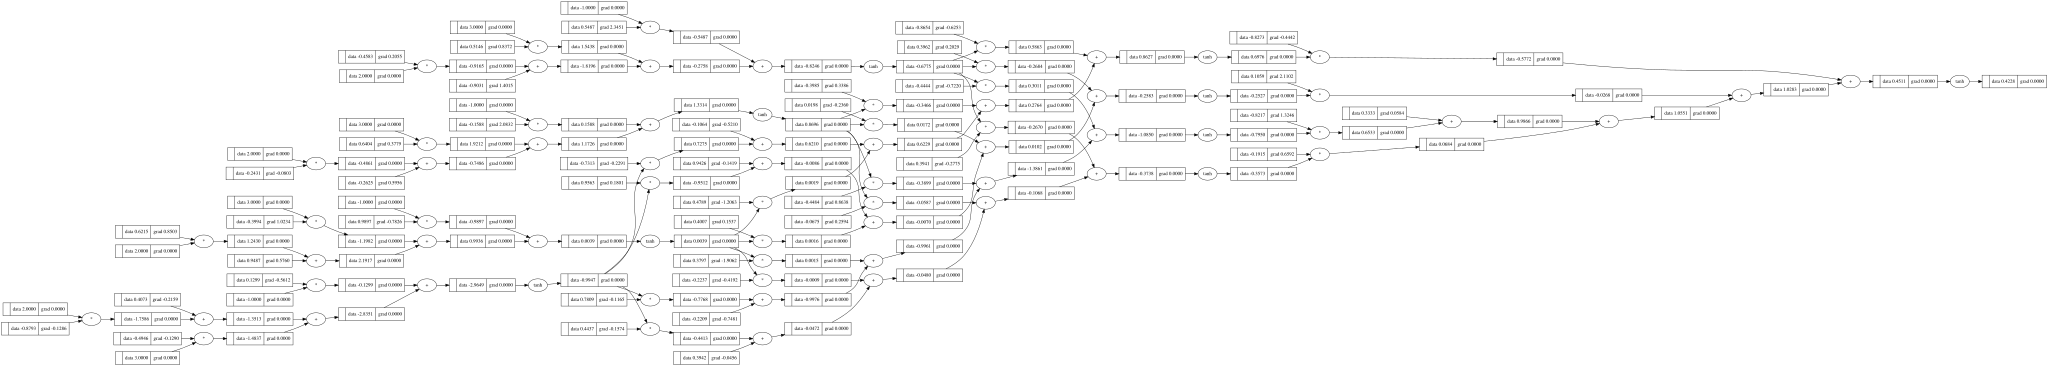

In [ ]:
draw_dot(n(x))

In [ ]:
# So the constructor will take number of inputs to this neuron which is how many inputs come to a neuron, so for example, 3 inputs.

# It's going to create a weight, that is some random number between -1 and 1 for every one of those inputs, and the bias that controls the overall trigger happiness of this neuron

# Now, we'd liek to actually do the forward pass of this neuron instead. So what we basically need to basically multiply all of the elements of w with all of the elements of x pairwise.
# We need to multiply them, so the first thing we're going to do is we're going to zip up.

# In Python, zip takes 2 iterators, and it creates a new iterator that iterates over the tuples of the corresponding entries

# So that's the raw activation w * x + b
# and of course we need to pass that through a non-linearity, so what we're going to be returning is act.tanh


# next up, we're going to define a layer of neurons (MLP - Multilayer Perceptron)
# where each layer has actually a number of neurons, but they are not connected with each other but all of them are fully connected to the input

# So what's a layer of neurons, it's just a set of neurons evaluated independently  A
# So the class Layer, is a list of neurons.

# and How many neurons do we have? we take 'nout' as an input argument, how many neurons do you want in your layer, nout = number of outputs
# 'nin' is the given dimensionality of the neurons


# Okay so finally, let's complete this picture and define an entire multi-layer perceptron or mlp
# as you can see, these layers just feed into each other sequentially

# so this is similar like before, we're taking nin as the number of inputs, as before.
# but now, instead of taking a single 'nout' which is number of neurons in a single layer, we're going to take a list of 'nouts' and this list defines the sized of all the layers that we want in our MLP

# This list of nouts and this list defines the sizes of all the layers that we want in our mlp.

In [ ]:
# So we wouldn't be able to differentiate on pen and paper these expressions.
# But with micrograd, we would be able to backpropagate all the way through this and backpropagate into these weights of all these neurons

# So let's create outselves a very simple example data set

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
# So we have 4 possible inputs into the neural net

ys = [1.0, -1.0, -1.0, 1.0] # Desired targets
# and we have 4 desired targets


# So it's a very simple binary classifier neural net that we would like here.
# Now let's think what the neural net currently thinks about these 4 examples
# We can get their predictions, basically we can just
# ypred = [n(x) for x in xs]
# ypred

# so how do we make the neural net and how do we tune the weights to better predict the desired targets. The trick used in deep learning to achieve this is:

# to calculate a single number that somehow measures the total performance of your neural net and we call this single number 'loss'

In [ ]:
# The loss is a single number that we're going to define that basically measures how well the neural net is performing.
# right now, we have the intuitive sense that it's not performing very well because we're not very close to the desired output.

# so the loss would be high and we'll want to minimize the loss
# so in particular in this case, what we're going to do is we're going to implement the mean squared error loss:

# We're going to basically iterate 'y ground truth' and 'y output' in 'zip'
# loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])

#loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
#loss
# so we're going to pair up the ground truths with the predictions and this zip iterates over tuples of them
# and for each 'y ground truth' and 'y output', we're going to subtract them, and square them

# The output is basically the losses are.
# so for basically for each one of the four;
# We are taking the prediction, and the ground truth,
# We are subtracting them and squaring them. - this makes sure that regardless of whether we are more negative or more positive, we always get a positive number
# instead of squaring, we can also take for example, the absolute value

# So looking at the expression, you only get zero exactly when 'yout' is equal to 'ygt' - when those two are equal, your prediction is exactly the target, you are going to get 0, and if your prediction is not the target, you are going to get some other number

# so you can see that we're way off, that's why the loss is quite high. The more off we are, the greater the loss would be, so we don't want high loss, we want low loss.

# so the final loss here, would be the sum of all these numbers.

# Now we want to minimize the loss, we want the loss to be low because if loss is low, then every one of the predictions is equal to its target.


# So the loss, the lowest it can be is 0, and the greater it is, the worse off the neural net is predicting

Value(data=2.855969494356943)

In [ ]:
# Now since we've changed all of these parameters, we should expect that the loss should have gone down a bit

for k in range(5000):
  # Forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0 # we need to reset it to 0 just like it is in the constructor
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -2000.5 * p.grad

  print(k, loss.data)

  # There's actually a bug here, a very subtle bug
  # So all of these weights here, have a .grad and .data
  # and .grad starts at 0.0, and we do backward() and we fill in the gradients
  # and we do an update on the data but we don't flush the grad, it stays there.


# So again, the way we've arranged this: Low loss means that our predictions are matching the targets, so our predictions now are probably slightly closer to the targets

# Now what we have to do is we have to iterate this process

# So this is gradient descent; just iteratively doing:
# Forward pass, backward pass, update
# So again, we've done the forward pass, and that's the loss
# Now we can run loss.backward
# Then the step size

# The neural net is then improving its predictions

0 6.6433626161224434e-09
1 6.6385360953747014e-09
2 6.6337165176370894e-09
3 6.6289038680240084e-09
4 6.624098131646008e-09
5 6.619299293663392e-09
6 6.6145073392890576e-09
7 6.609722253769352e-09
8 6.604944022381711e-09
9 6.6001726304530786e-09
10 6.595408063417501e-09
11 6.590650306615523e-09
12 6.585899345534179e-09
13 6.581155165679667e-09
14 6.5764177525836825e-09
15 6.5716870918225425e-09
16 6.566963169030153e-09
17 6.562245969861448e-09
18 6.557535479998107e-09
19 6.552831685234001e-09
20 6.548134571290387e-09
21 6.543444124034715e-09
22 6.538760329309879e-09
23 6.534083173058168e-09
24 6.529412641176074e-09
25 6.524748719643225e-09
26 6.52009139448517e-09
27 6.515440651831506e-09
28 6.51079647770254e-09
29 6.5061588582588515e-09
30 6.501527779707435e-09
31 6.496903228226544e-09
32 6.492285190103192e-09
33 6.487673651602245e-09
34 6.4830685990911655e-09
35 6.478470018907247e-09
36 6.473877897484436e-09
37 6.469292221234329e-09
38 6.464712976692591e-09
39 6.460140150365267e-09
40

In [ ]:
ypred

[Value(data=0.9999803088509372),
 Value(data=-0.9999847883793888),
 Value(data=-0.9999820237617887),
 Value(data=0.9999782906057634)]

In [ ]:
# SO TO SUMMARIZE EVERYTHING:
# Neural Nets are these mathematical expressions
# fairly simple mathematical expressions, in case of multi-layer perceptron
# that take input as the data and they take the input, the weights, and the parameters
# of the neural net
# Mathematical expression for the forward pass, followed by a loss function

# and the loss function tries to measure the accuracy of the predictions, and usually the loss will be low when your predictions are matching your targets or where the networks is basically behaving well.

# So we manipulate the loss function so that when the loss is low, the network is doing what you want it to do on your problem.

# Then, we backward the loss, use backpropagation to get the gradient, and then we know how to tune all the parameters to decrease the loss locally

# But then we need to iterate that process many times, in what's called the gradient descent.

# So we simply follow the gradient information, and that minimizes the loss, and the loss is arranged, so that when the loss is minimized, the network is doing what you want it to do.

# We just have a blob of neural stuff and we make it do arbitrary things and that's what gives neural nets their power.

# You know, this is a tiny network with 41 parameters, but you can build significantly more complicated neural nets with billions, at this point almost trillions of parameters, and it's a massive blob of neural tissue, simulated neural tissue, roughly speaking. This, you can make it do extremely complex problems and these neurons then have all kinds of very fascinating emergent properties, when you try to make them do significantly hard problems

# As in case of GPT for example, we have massive amounts of text from the internet and we're trying to get a neural net to predict, to take like a few words and try to predict the next word in a sequence. That's the learning problem, and as it turns out when you train this on all of internet, the neural net actually has like really remarkable emergent properties but that neural net would have hundreds of biliions of parameters

# But it works fundamentally on the exact same principles
# The Neural net, of course would be a bit more complex, but otherwise the value in the gradient is there and would be identical, the gradient descent would be there and would basically be identical, but people use slightly different updates
# The one we have on the update is a very simple stochastic gradient descent update
# The loss function would not be mean squared error, they would be using something called cross-entropy loss for predicting the next token.

# So there's a few more details, but fundamentally, the neural network setup, and the neural network training is identical and pervasive

# Now, you understand intuitively

In [ ]:
# Forward Pass
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

In [ ]:
# so now we can do backpropagation
loss.backward() # something magical happened when we hit enter

In [ ]:
for p in n.parameters(): # so for all the 41 parameters (weights & bias)
  p.data += -0.01 * p.grad

In [ ]:
# So now if we look at ypred now, we can see the value getting closer to the prediction values
ypred

[Value(data=0.9971936631446696),
 Value(data=-0.9998582933618019),
 Value(data=-0.9977512828891282),
 Value(data=0.9971182739197503)]

In [ ]:
# NOTE: So we also don't want to do overstep, because we don't really know about the loss function
# The loss function has all kinds of structure and we only know the very local dependence of all these parameters on the loss, but if we step too far, we may step into a part of the loss that is completely different and that can destabilize training and make you loss actually blow up, even.

# So usually, this learning rate and the tuning of it is a subtle art, you want to set your learning rate if its too low, you're going to take way too long to converge, but if its too high, the whole thing gets unstable and you might actually even explode the loss, depending on your loss function
# So finding those step size to be just right, it's a pretty subtle art sometimes, when you're using sort of vanilla gradient descent

# So basically, we're successfully trained neural net.

# Okay let's make this a tiny bit more respectable and implement and actual training loop and what that looks like.

In [ ]:
# The magical thing that happened is that we can look at the:
n.layers[0].neurons[0].w[0].grad

# since that because this gradient here on this particular weight of this,
# of this particular neuron, of this particular layer is negative,
# we see that its influence on the loss is also negative.

# So slightly increasing this particular weight of this neuron of this layer would make the loss go down

# and we actually have this information for every single one of our neurons and all their parameters



-0.12863925862601827

In [ ]:
n.layers[0].neurons[0].w[0].data

-0.8805944187510546

In [ ]:
# What we want to do now is we want to iterate for every p in n.parameters
for p in n.parameters(): # so for all the 41 parameters (weights & bias)
  p.data += -0.01 * p.grad
  # we actually want to change its data slightly according to the gradient information
  # basically this would be a tiny update on this gradient descent scheme

  # And for gradient descent, we are thinking of the gradient as a vector pointing to the direction of increased loss

  # so we are modifying the p.data by a small step size, in the direction of the gradient

  # So the gradient is negative, so this value of the neuron would slightly go down
  # if the value of this neuron goes lower, that would actually increase the loss
    # That's because the derivative of this neuron is negative,

  #so increasing the data value, makes the loss goes down, so increasing it is what we want to do instead of decreasing it


# That's because we want to minimize the loss, we don't want to maximuze the loss. We want to decrease it.
# Another interpretation as mentioned is you can think of the gradient vector, so basically just the vector of all the gradients, as pointing in the direction of increasing the loss

# So if we nudge all parameters in a tiny amount, then we'll see that this data will have changed a little bit

In [ ]:
n.layers[0].neurons[0].w[0].data
# So now this neuron is now a tiny amount greater.

# This is a good thing because, slightly increasing this neuron data makes the loss go down



-0.8793080261647944

In [ ]:
# These input data are not useful to us because the input data seems to be not changeable , it a given to the problem. So it's a fixed input and we're not going to be changing it or messing with it even though we do have gradients for it
# but some of the gradients here would be for the neural network parameters

# the w's and the b's, and those of course we want to change

In [ ]:
# Okay so now we're going to want some convenience code to gather up all of the parameters of the neural net so that we can operate on all of them simultaneously.

# and every one of them will nudge a tiny amount based on gradient information. So let's collect all the parameters of the neural net, all in one array

# so that's parameters of Neuron and, We're calling 'parameters' this way because also PyTorch has a parameters on every single and in module and it does exactly what we're doing here, it just returns the parameter Tensors.
# For us it's the parameter Scalars

# Now Layer is also a module, so it will have parameters
